- ### Scipy

1. [Linear algebra](#linear-algebra)

2. [Optimization](#optimization)

3. [Root Finding](#root-finding)

4. [Integration](#integration)

5. [ODE](#ode)

6. [Statistics](#statistics)

5. [Spatial search](#spatial-search)

6. [Signal processing](#signal-processing)

7. [Interpolation](#interpolation)

---

- ### Linear algebra

**matrix attribution**

In [12]:
import scipy.linalg as la
A = [[1,2,-3],[4,5,6],[7,8,9]]
b = [-1,2,3]
norm = la.norm(b)
det = la.det(A)
inv = la.inv(A)
print(norm)
print(det)
print(inv)

3.7416573867739413
18.000000000000032
[[-0.16666667 -2.33333333  1.5       ]
 [ 0.33333333  1.66666667 -1.        ]
 [-0.16666667  0.33333333 -0.16666667]]


**eigen system**

In [47]:
import scipy.linalg as la
A = [[1,2,-3],[2,5,6],[-3,6,9]]
eigenvalues, eigenvectors = la.eig(A)
print(eigenvalues)
print(eigenvectors)

[-2.59096917+0.j  4.12827017+0.j 13.46269899+0.j]
[[-0.69422282  0.71152408 -0.10857332]
 [ 0.54993772  0.62167465  0.55775365]
 [-0.46435244 -0.32749675  0.82287465]]


**Hermitian eigen system**

In [41]:
import scipy.linalg as la
import numpy as np
A = np.array([[1,complex(2,3),-3],[complex(2,-3),5,6],[-3,6,9]])
 # only applicable if A is Hermitian, i.e. A^H=A
if not la.norm(np.conjugate((A.T)) - A):
    eigenvalues, eigenvectors = la.eigh(A)
else: raise TypeError("Matrix is not Hermitian, use eigen instead")
print(eigenvalues)
print(eigenvectors)

[-3.46386516  4.72946215 13.73440301]
[[ 0.70225748+0.j          0.68722273+0.j          0.18590143+0.j        ]
 [-0.43380697+0.37786146j  0.52345558-0.25267667j -0.29632038-0.49333074j]
 [ 0.37786146-0.18189933j -0.25267667+0.35500447j -0.49333074-0.62520753j]]


**eigen system**

In [ ]:
import scipy.linalg as la
A = [[1,2,-3],[2,5,6],[-3,6,9]]
b = [-1,2,3]
eigenvalues, eigenvectors = la.eig(A)
print(eigenvalues)
print(eigenvectors)

[-2.59096917+0.j  4.12827017+0.j 13.46269899+0.j]
[[-0.69422282  0.71152408 -0.10857332]
 [ 0.54993772  0.62167465  0.55775365]
 [-0.46435244 -0.32749675  0.82287465]]


**singular value decomposition**

In [ ]:
import scipy.linalg as la
A = [[1,2,-3],[2,5,6]]
U, S, V = la.svd(A)
print(U,"\n")
print(S,"\n")
print(V)

[[-0.1152884   0.99333206]
 [ 0.99333206  0.1152884 ]] 

[8.10532996 3.64741363] 

[[ 0.23088211  0.58431717  0.777989  ]
 [ 0.33555527  0.7027188  -0.62736668]
 [ 0.91328862 -0.40590605  0.0338255 ]]


**LU decomposition**

In [45]:
import scipy.linalg as la
A = [[1,2,-3],[2,5,6],[-3,6,9]]
P, L, U = la.lu(A)
print(P,"\n")
print(L,"\n")
print(U)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]] 

[[ 1.          0.          0.        ]
 [-0.66666667  1.          0.        ]
 [-0.33333333  0.44444444  1.        ]] 

[[-3.          6.          9.        ]
 [ 0.          9.         12.        ]
 [ 0.          0.         -5.33333333]]


**QR decomposition**

In [46]:
import scipy.linalg as la
A = [[1,2,-3],[2,5,6],[-3,6,9]]
Q, R = la.qr(A)
print(Q,"\n")
print(R)

[[-0.26726124 -0.30736838  0.91328862]
 [-0.53452248 -0.7413002  -0.40590605]
 [ 0.80178373 -0.59665626  0.0338255 ]] 

[[-3.74165739  1.60356745  4.81070235]
 [ 0.         -7.90117532 -8.89560242]
 [ 0.          0.         -4.87087266]]


**linear equation**

In [48]:
import scipy.linalg as la
A = [[1,2,-3],[2,5,6],[-3,6,9]]
b = [-1,2,3]
sol = la.solve(A, b)
print(sol)

[-0.          0.          0.33333333]


---

- ### Optimization

**scalar minimization**

In [61]:
import scipy.optimize as opt
f = lambda x: x**2 + 4*x + 1
res = opt.minimize_scalar(f)
print(res.x)
print(res.fun)

-2.0
-3.0


In [100]:
import scipy.optimize as opt
f = lambda x: x**2 + 4*x + 1
res = opt.minimize(f, x0=0, bounds=[(-10,10)])
print(res.x)
print(res.fun)

[-1.99999999]
-3.0


**multivariate local minimization**

In [93]:
import scipy.optimize as opt
f = lambda v: v[0]**2 + v[1]**2 + 4*v[0] + 1
res = opt.minimize(f, [0,0], method='BFGS')
print(res.x)
print(res.fun)

[-2.00000001e+00  7.15550825e-09]
-3.0


**global optimization**

In [132]:
import scipy.optimize as opt
import numpy as np
f = lambda x: np.sin(x) + np.exp(x)
res = opt.differential_evolution(f, bounds=[(-5, 5)])
print(res)

             message: Optimization terminated successfully.
             success: True
                 fun: -0.8102206373303151
                   x: [-1.746e+00]
                 nit: 5
                nfev: 96
          population: [[-1.745e+00]
                       [-1.698e+00]
                       ...
                       [-1.734e+00]
                       [-1.692e+00]]
 population_energies: [-8.102e-01 -8.089e-01 ... -8.101e-01 -8.085e-01]
                 jac: [-3.331e-08]


**constrained optimization**

In [65]:
import scipy.optimize as opt
f = lambda x: x[0]**2 + x[1]**2 
cons = [{"type":"eq", "fun": lambda x:x[0] + x[1] - 2},
        {"type":"ineq", "fun": lambda x: x[0]}]
res = opt.minimize(f, x0=[0,0], constraints=cons)
print(res.x)
print(res.fun)

[1. 1.]
1.9999999999999993


**least squares**

In [84]:
import scipy.optimize as opt
f = lambda x: [x[0]**2 - x[1] - 2, x[1]**2 - x[0] - 2]
res = opt.least_squares(f, x0=[1, 1])
print(res.x)

[2. 2.]


**curve fitting**

In [87]:
import scipy.optimize as opt
import numpy as np

def model(x, a, b):
    return a * np.exp(b*x)

xdata = np.linspace(0,10,100)
ydata = model(xdata,2,3) + np.random.randn(100)

popt, pcov = opt.curve_fit(model, xdata=xdata, ydata=ydata)
print(popt)
print(pcov)

[2. 3.]
[[ 1.69490511e-23 -8.57615524e-25]
 [-8.57615524e-25  4.34069993e-26]]


C:\Users\Taylor\AppData\Local\Temp\ipykernel_18200\1803350963.py:5: RuntimeWarning: overflow encountered in exp
  return a * np.exp(b*x)


---

- ## Root Finding

**single equation**

In [75]:
import scipy.optimize as opt
f = lambda x: x**2 - 5
root = opt.fsolve(f,x0=0)
print(root)

[2.23606798]


**system of nonlinear equations**

In [80]:
import scipy.optimize as opt
f = lambda x: [x[0]**2 - x[1] - 2, x[1]**2 - x[0] - 2]
root = opt.fsolve(f,x0=[0,0])
print(root)

[-1. -1.]


**linear programming**

Solve:

min cᵀx
s.t. Ax ≤ b

In [91]:
from scipy.optimize import linprog
import numpy as np

c = [-3, -4]
A = [[1, 2],
     [4, 1]]
b = [8, 7]

res = linprog(c, A_ub=A, b_ub=b)
print(res.x)

[0.85714286 3.57142857]


---

- ### Integration

**single-variable numerical integration**

In [133]:
import scipy.integrate as ig
import numpy as np
f = lambda x: np.sin(x)
I, error = ig.quad(f, 0, np.pi)
print(I)
print(error)

2.0
2.220446049250313e-14


In [134]:
import scipy.integrate as ig
import numpy as np
f = lambda x: np.exp(-x)
I, error = ig.quad(f, 0, np.inf)
print(I)
print(error)

1.0000000000000002
5.842606703608969e-11


In [137]:
import scipy.integrate as ig
def f(x, a, b):
    return a * x + b
I, error = ig.quad(f, 0, 1, args=(2, 3))
print(I)
print(error)

4.0
4.440892098500626e-14


**two-variable numerical integration**

In [138]:
import scipy.integrate as ig
f = lambda y, x : x * y
I, error = ig.dblquad(f, 0, 1, lambda y: y - 1, lambda y: y**2)
print(I)
print(error)

0.04166666666666667
5.491081814912553e-15


**three-variable numerical integration**

In [166]:
import scipy.integrate as ig
import numpy as np
f = lambda z, y, x : x * y * np.sin(z)
I, error = ig.tplquad(f, 0, 1, lambda z: z - 1, lambda z: z**2, lambda z, y: z + y, lambda z, y: z * y)
print(I)
print(error)

-0.054335589793174474
1.0519734834229275e-14


**n-variable numerical integration**

In [181]:
import scipy.integrate as ig
import numpy as np
f = lambda z, y, x : x * y * np.sin(z)
I, error = ig.nquad(f, [(0, 1), (2, 3), (4, 5)])
print(I)
print(error)

5.1715990589834275
7.646641110200747e-14


**trapezoidal Rule**

In [151]:
import scipy.integrate as ig
import numpy as np
x = np.linspace(0, np.pi, 100)
y = np.sin(x)
res = ig.trapezoid(y, x)
print(res)

1.9998321638939927


**Simpson’s Rule**

In [152]:
import scipy.integrate as ig
import numpy as np
x = np.linspace(0, np.pi, 100)
y = np.sin(x)
res = ig.simpson(y, x)
print(res)

2.0000000534993037


---

- ### ODE

**ODE**

$$\frac{dy}{dt}= f(x,y)$$
$$y(x_0)=y_0$$

(100,)
(100,)


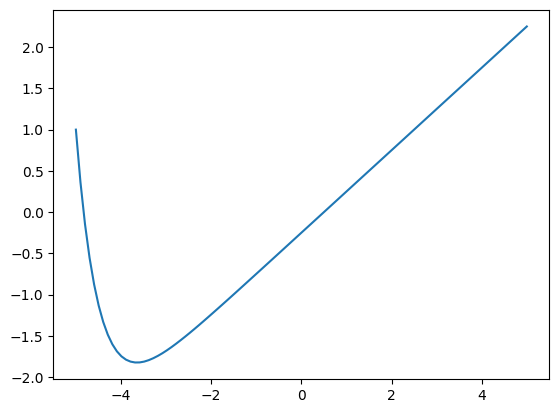

In [202]:
import scipy.integrate as ig
import matplotlib.pyplot as plt

def f(t, y):
    return -2*y + t

sol = ig.solve_ivp(f, t_span = (-5, 5), y0 = [1.0], t_eval=np.linspace(-5, 5, 100))
print(sol.t.shape)
print(sol.y[0].shape)
plt.plot(sol.t, sol.y[0])

**system of ODEs**

(200,)
(2, 200)


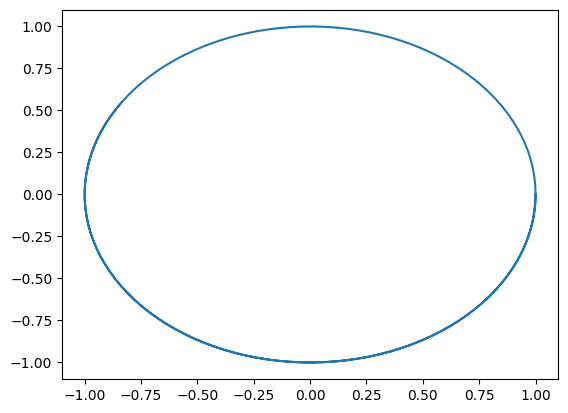

In [2]:
import scipy.integrate as ig
import matplotlib.pyplot as plt
import numpy as np

def f(t, Y):
    x, y = Y
    return [y, -x]     # harmonic oscillator

sol = ig.solve_ivp(f, (0,10), [1,0], t_eval=np.linspace(0,10,200))
print(sol.t.shape)
print(sol.y.shape)
plt.plot(sol.y[0],sol.y[1])

---

- ### Statistics

**distribution pdf**

In [7]:
import scipy.stats as st
x = 0.5
# continuous distributions
y1 = st.norm.pdf(x, loc=0, scale=1)
y2 = st.expon.pdf(x, scale=1)
y3 = st.uniform.pdf(x, loc=0, scale=1)
y4 = st.gamma.pdf(x, a=2, scale=1)
y5 = st.beta.pdf(x, a=2, b=5, loc=0, scale=1)
y6 = st.chi2.pdf(x, df=3)
print(y1, "\n", y2, "\n", y3, "\n", y4, "\n", y5, "\n", y6)

# discrete distributions
k = 3
z1 = st.poisson.pmf(k, mu=2)
z2 = st.binom.pmf(k, n=10, p=0.5)
z3 = st.geom.pmf(k, p=1)
z4 = st.bernoulli.pmf(k, p=1)
print(z1, "\n", z2, "\n", z3, "\n", z4)

0.3520653267642995 
 0.6065306597126334 
 1.0 
 0.3032653298563167 
 0.9374999999999999 
 0.21969564473386122
0.18044704431548356 
 0.11718749999999999 
 0.0 
 0.0


**distribution cdf**

In [5]:
import scipy.stats as st
x = 0.5
# continuous cumulative distribution
y1 = st.norm.cdf(x, loc=0, scale=1)
y2 = st.expon.cdf(x, scale=1)
y3 = st.uniform.cdf(x, loc=0, scale=1)
y4 = st.gamma.cdf(x, a=2, scale=1)
y5 = st.beta.cdf(x, a=2, b=5, loc=0, scale=1)
y6 = st.chi2.cdf(x, df=3)
print(y1, "\n", y2, "\n", y3, "\n", y4, "\n", y5, "\n", y6)


# discrete cumulative distributions
k = 0.5
z1 = st.poisson.cdf(k, mu=2)
z2 = st.binom.cdf(k, n=10, p=0.5)
z3 = st.geom.cdf(k, p=0.5)
z4 = st.bernoulli.cdf(k, p=0.5)
print(z1, "\n", z2, "\n", z3, "\n", z4)

0.6914624612740131 
 0.3934693402873666 
 0.5 
 0.09020401043104986 
 0.890625 
 0.08110858834532418
0.1353352832366127 
 0.0009765625 
 0.0 
 0.5


**distribution ppf**

In [4]:
import scipy.stats as st
x = 0.5
# continuous percentile distribution
y1 = st.norm.ppf(x, loc=0, scale=1)
y2 = st.expon.ppf(x, scale=1)
y3 = st.uniform.ppf(x, loc=0, scale=1)
y4 = st.gamma.ppf(x, a=2, scale=1)
y5 = st.beta.ppf(x, a=2, b=5, loc=0, scale=1)
y6 = st.chi2.ppf(x, df=3)
print(y1, "\n", y2, "\n", y3, "\n", y4, "\n", y5, "\n", y6)


# discrete percentile distributions
k = 0.5
z1 = st.poisson.ppf(k, mu=2)
z2 = st.binom.ppf(k, n=10, p=0.5)
z3 = st.geom.ppf(k, p=0.5)
z4 = st.bernoulli.ppf(k, p=0.5)
print(z1, "\n", z2, "\n", z3, "\n", z4)

0.0 
 0.6931471805599453 
 0.5 
 1.6783469900166612 
 0.26444998329566 
 2.365973884375337
2.0 
 5.0 
 1.0 
 0.0


**sampling**

In [ ]:
import scipy.stats as st
# continuous distributions samples
samples1 = st.norm.rvs(size=5) # random variant sample
samples2 = st.expon.rvs(size=5)
samples3 = st.uniform.rvs(size=5)
samples4 = st.gamma.rvs(a=5, size=5)
samples5 = st.beta.rvs(a=5, b=10, size=5)
samples6 = st.chi2.rvs(df=5, size=5)
print(samples1, "\n", samples2, "\n", samples3, "\n", samples4, "\n", samples5, "\n", samples6)

# discrete distributions samples
samples7 = st.poisson.rvs(mu=5, size=5)
samples8 = st.binom.rvs(n=10, p=0.5, size=5)
samples9 = st.geom.rvs(p=0.5, size=5)
samples10 = st.bernoulli.rvs(p=0.5, size=5)
print(samples7, "\n", samples8, "\n", samples9, "\n", samples10)

[ 0.45233559  1.28387829 -0.57509441  1.31096262  0.43225101] 
 [0.6489845  0.19434514 0.18127794 0.67059776 0.08645139] 
 [0.83137154 0.19912169 0.43832355 0.21988091 0.69658838] 
 [ 6.51996888  1.94166944  5.32801623 11.01755722  1.43820207] 
 [0.30824859 0.40249076 0.43081972 0.21065209 0.2573832 ] 
 [ 3.74308838  5.83597248  1.71385981  2.91951677 16.01795614]
[5 2 3 5 1] 
 [5 5 6 7 6] 
 [1 4 2 2 2] 
 [0 1 1 0 1]


**distribution attribution**

In [ ]:
import scipy.stats as st
rv = st.norm(loc=2, scale=0.5)
print("Mean: ",rv.mean())
print("variance: ",rv.var())
print("Standard deviation: ",rv.std())
print("Probability Density Function: ",rv.pdf(2))
print("Cumulative Distribution Function: ",rv.cdf(1.5))
print("Percent point function: ", rv.ppf(0.95))
print("Random variant sample: ", rv.rvs(size=5))

Mean:  2.0
variance:  0.25
Standard deviation:  0.5
Probability Density Function:  0.7978845608028654
Cumulative Distribution Function:  0.15865525393145707
Percent point function:  2.822426813475736
Random variant sample:  [1.63644999 3.33756505 2.05077006 1.36390658 1.7133578 ]


**data atrribution**

In [27]:
import scipy.stats as st
data = [3,5,1,7,8,2,4,6,9,10]
print(st.describe(data)) # gives the mean, variance, skewness, kurtosis
print(st.sem(data)) # standard error of the mean
print(st.variation(data)) # coefficient of variation
print(st.skew(data)) # skewness
print(st.kurtosis(data)) # kurtosis
print(st.tmean(data)) # trimmed mean
print(st.tvar(data)) # trimmed variance
print(st.iqr(data)) # interquartile range

DescribeResult(nobs=10, minmax=(np.int64(1), np.int64(10)), mean=np.float64(5.5), variance=np.float64(9.166666666666668), skewness=np.float64(0.0), kurtosis=np.float64(-1.2242424242424244))
0.9574271077563381
0.5222329678670935
0.0
-1.2242424242424244
5.5
9.166666666666668
4.5


**data distribution fitting**

In [18]:
import scipy.stats as st
data = [3,5,1,7,8,2,4,6,9,10]
mu, sigma = st.norm.fit(data)
print(mu, sigma)

5.5 2.8722813232690143


**hypothesis tests**

In [63]:
import scipy.stats as st
data = [3,5,1,7,8,2,4,6,9,10]
alpha = 0.05 # significance level

# T-test with one sample
mean_h = 5 # null hypothesis: mean = 5
t_stats, p_value = st.ttest_1samp(data, popmean=mean_h)
print("t_stats: ",t_stats, "p_value: ",p_value)
if p_value < alpha: # compare with the significance level
    print(f"Reject null hypothesis, data has a different mean than {mean_h}") 
else:
    print(f"Fail to reject null hypothesis, data has a mean equal to {mean_h}")
print("\n")

# T-test with two samples
data1 = [3,5,1,7,8,2,4,6,9,10]
data2 = [4,6,7,8,9,10,11,12,13,14]
t_stats, p_value = st.ttest_ind(data1, data2)
print("t_stats: ",t_stats, "p_value: ",p_value)
if p_value < alpha: # compare with the significance level
    print("Reject null hypothesis, data has a different mean") 
else:
    print("Fail to reject null hypothesis, data has the same mean")  
print("\n")  

# Paired T-test
data1 = [3,5,1,7,8,2,4,6,9,10]
data2 = [4,6,7,8,9,10,11,12,13,14]
t_stats, p_value = st.ttest_rel(data1, data2)
print("t_stats: ",t_stats, "p_value: ",p_value)
if p_value < alpha: # compare with the significance level
    print("Reject null hypothesis, data has a different mean")
else:
    print("Fail to reject null hypothesis, data has the same mean")

t_stats:  0.5222329678670935 p_value:  0.614117254808394
Fail to reject null hypothesis, data has a mean equal to 5


t_stats:  -2.7976343841740405 p_value:  0.011896872095673668
Reject null hypothesis, data has a different mean


t_stats:  -4.457345008892837 p_value:  0.0015833118640585803
Reject null hypothesis, data has a different mean


In [78]:
import scipy.stats as st
alpha = 0.05 # significance level
table = [[10, 20, 30, 15, 25, 35], [5, 10, 15, 20, 25, 30], [20, 25, 30, 35, 40, 45]]
# chi-square test
res = st.chi2_contingency(table)
print("Chi_square_stats: ", res[0], "p-value: ", res[1])
if res[1] < alpha:
    print("Reject null hypothesis, data is significant")
else:
    print("Fail to reject null hypothesis, data is not significant")

Chi_square_stats:  11.560922322827084 p-value:  0.3155160784682205
Fail to reject null hypothesis, data is not significant


---

- ### Spatial search

**Delaunay triangulation**

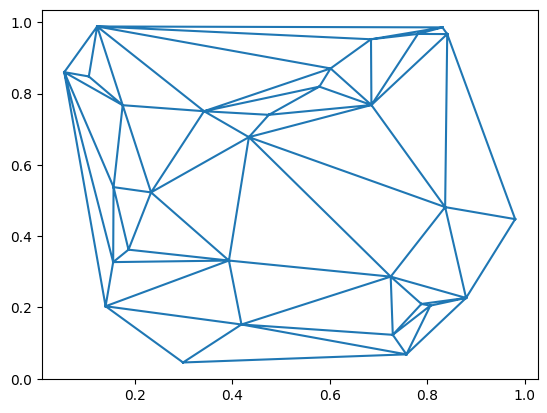

In [103]:
from scipy.spatial import Delaunay

points = np.random.rand(30,2)
tri = Delaunay(points)
simplices = tri.simplices
plt.triplot(points[:,0], points[:,1], simplices)

**convex hull**

[ 2  9 18  8 17  3  6 16 15]
[[ 9  2]
 [15  2]
 [ 3  6]
 [18  9]
 [18  8]
 [16  6]
 [16 15]
 [17  8]
 [17  3]]


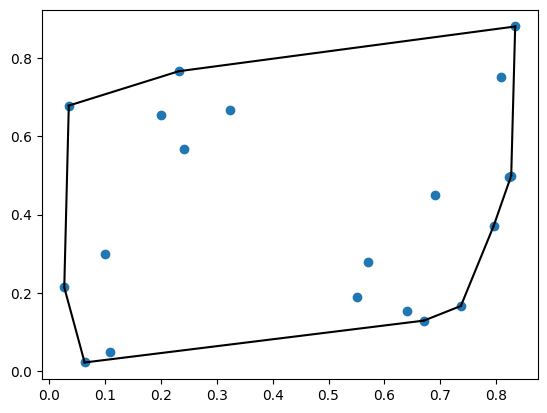

In [18]:
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import numpy as np

points = np.random.rand(20, 2)
hull = ConvexHull(points)
print(hull.vertices)
print(hull.simplices)

plt.plot(points[:,0], points[:,1], 'o')
for simplex in hull.simplices:
    plt.plot(points[simplex,0], points[simplex,1], 'k-')
plt.show()

Convex hull indices:
 [19, 17, 11, 7, 18, 1, 10]
Simplex vertices:
 [[0.02305817 0.41288861]
 [0.05669301 0.90339783]
 [0.30128098 0.9039032 ]
 [0.82727837 0.40995353]
 [0.78634183 0.15991716]
 [0.7103444  0.1083658 ]
 [0.25458924 0.04747786]]


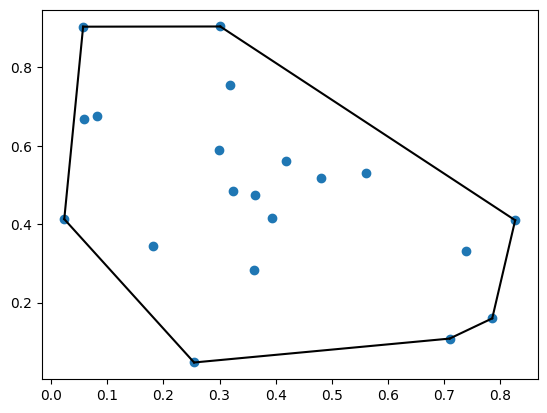

In [99]:
import matplotlib.pyplot as plt
import numpy as np

points = np.random.rand(20, 2)

idx = int(np.argmin(points[:, 0]))
idx_c = idx
hull = [idx]
u = np.array([0, -1])

while True:
    theta_min = np.inf
    for i in range(len(points)):
        if i == idx:
            continue
        v = points[i] - points[idx]
        k = u @ v / (np.linalg.norm(u) * np.linalg.norm(v))
        if k < theta_min:
            theta_min = k
            theta_min_idx = i
    if theta_min_idx != idx_c:
        hull.append(theta_min_idx)
        u = points[idx] - points[theta_min_idx]
        idx = theta_min_idx
    else:
        break

print("Convex hull indices:\n",hull) 
print("Simplex vertices:\n",points[hull])   
simplices = [[hull[i-1], hull[i]] for i in range(len(hull))]

plt.plot(points[:,0], points[:,1], 'o')
for simplex in simplices:
    plt.plot(points[simplex,0], points[simplex,1], 'k-')
plt.show()

Convex hull indices: [12, 16, 6, 7, 4, 9, 5, 17]
Edges: [(17, 12), (12, 16), (16, 6), (6, 7), (7, 4), (4, 9), (9, 5), (5, 17)]


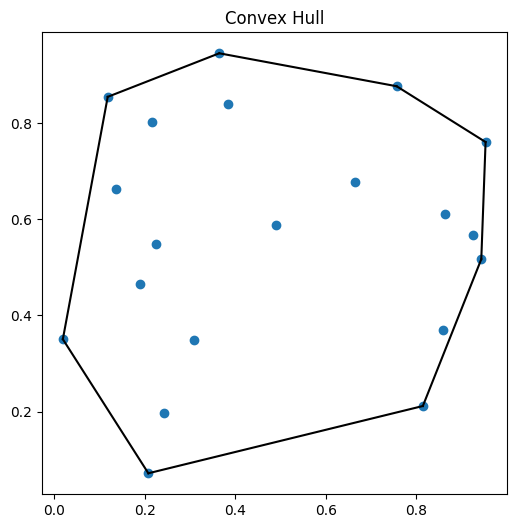

In [93]:
import numpy as np
import matplotlib.pyplot as plt

points = np.random.rand(20, 2)
start = np.argmin(points[:, 0])
hull = [int(start)]
current = start

def orientation(a, b, c):
    """Cross product of AB × AC"""
    AB = b - a
    AC = c - a
    return AB[0]*AC[1] - AB[1]*AC[0]

while True:
    next_point = None
    for i in range(len(points)):
        if i == current:
            continue
        if next_point is None:
            next_point = i
            continue
        
        # If point i is more left-turn than next_point
        o = orientation(points[current], points[next_point], points[i])
        if o < 0:     # right-turn means next_point is worse
            next_point = i
    
    if next_point == start:
        break
    
    hull.append(next_point)
    current = next_point

# Build edges
edges = [(hull[i-1], hull[i]) for i in range(len(hull))]

print("Convex hull indices:", hull)
print("Edges:", edges)

# Plot
plt.figure(figsize=(6,6))
plt.plot(points[:,0], points[:,1], "o")

for a, b in edges:
    plt.plot([points[a,0], points[b,0]],
             [points[a,1], points[b,1]], "k-")

plt.title("Convex Hull")
plt.show()

**Voronoi plot**

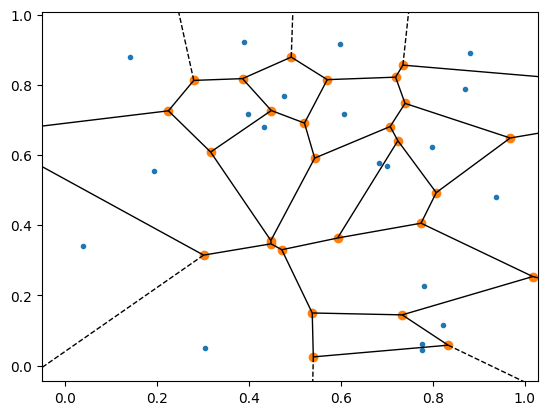

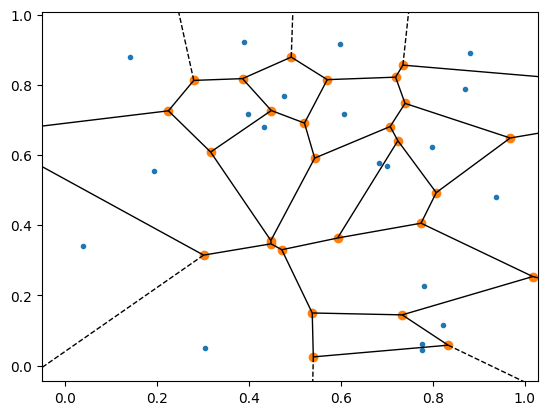

In [97]:
from scipy.spatial import Voronoi, voronoi_plot_2d
import numpy as np
points = np.random.rand(20,2)
v = Voronoi(points)
voronoi_plot_2d(v)

---

- ### Signal processing

**Fast Fourier Transform**

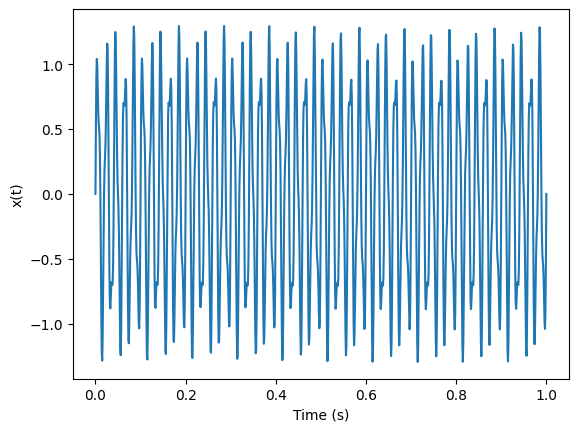

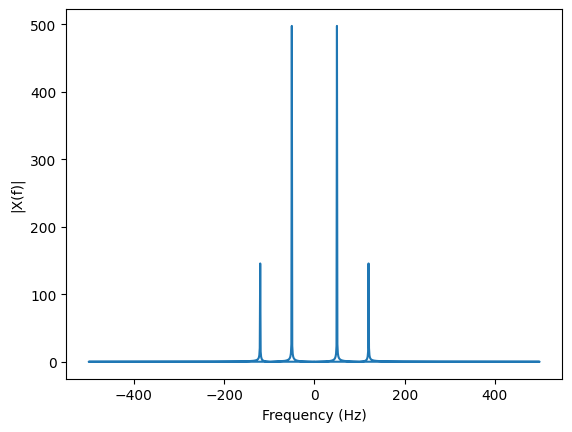

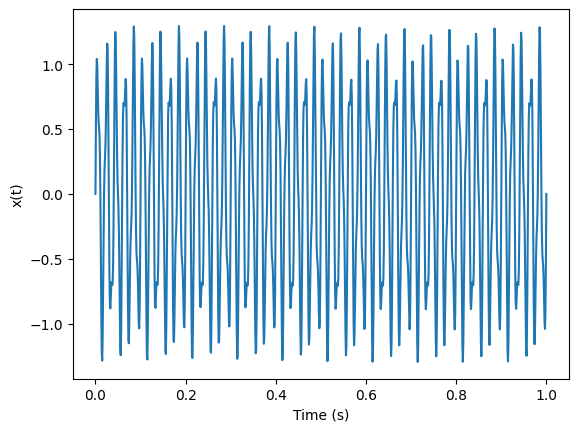

In [122]:
import numpy as np
from scipy import fft
import matplotlib.pyplot as plt

fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*50*t) + 0.3*np.sin(2*np.pi*120*t)
plt.plot(t, np.real(x))
plt.xlabel("Time (s)")
plt.ylabel("x(t)")
plt.show()

X = fft.fft(x)
f = fft.fftfreq(len(x), 1/fs)

plt.plot(f, np.abs(X))
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)|")
plt.show()

x = fft.ifft(X)
plt.plot(t, np.real(x))
plt.xlabel("Time (s)")
plt.ylabel("x(t)")
plt.show()

**Real Fast Fourier Transform**

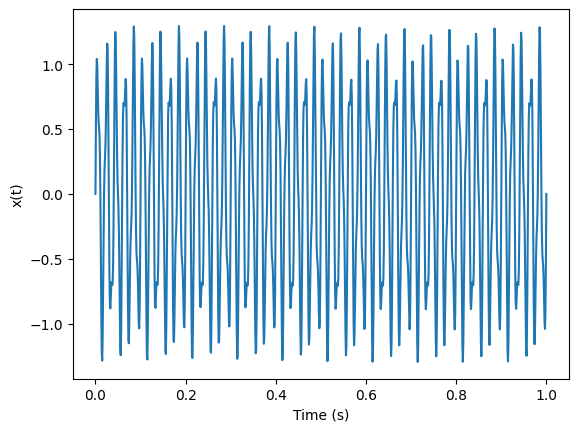

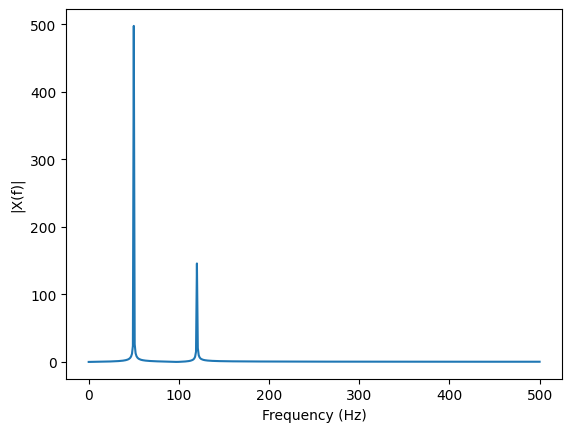

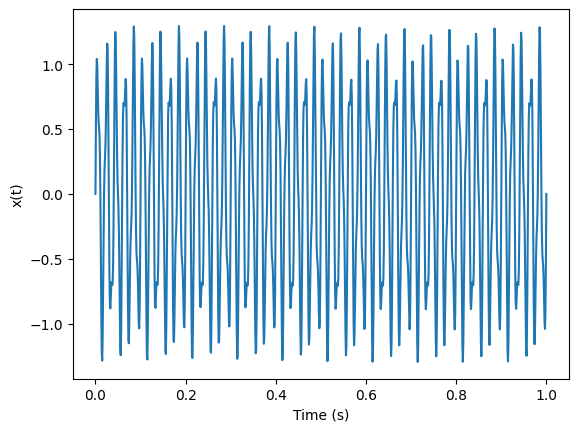

In [123]:
import numpy as np
from scipy import fft
import matplotlib.pyplot as plt

fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*50*t) + 0.3*np.sin(2*np.pi*120*t)
plt.plot(t, np.real(x))
plt.xlabel("Time (s)")
plt.ylabel("x(t)")
plt.show()

X = fft.rfft(x)
f = fft.rfftfreq(len(x), 1/fs)

plt.plot(f, np.abs(X))
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)|")
plt.show()

x = fft.irfft(X)
plt.plot(t, np.real(x))
plt.xlabel("Time (s)")
plt.ylabel("x(t)")
plt.show()

---

- ### Interpolation

**zero**

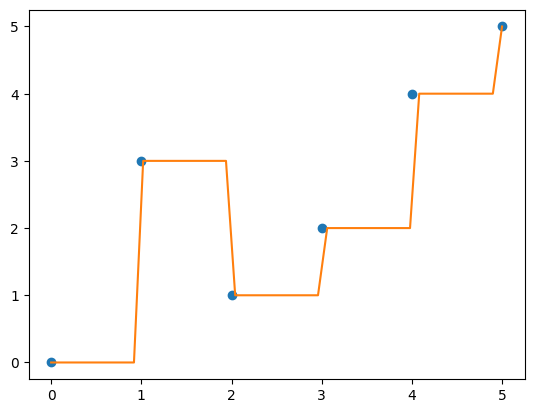

In [137]:
from scipy.interpolate import interp1d
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 3, 1, 2, 4, 5])

f = interp1d(x, y, kind='zero')

X = np.linspace(0, 5, 50)
Y = f(X)
plt.plot(x, y, 'o') 
plt.plot(X, Y, '-')
plt.show()

**linear**

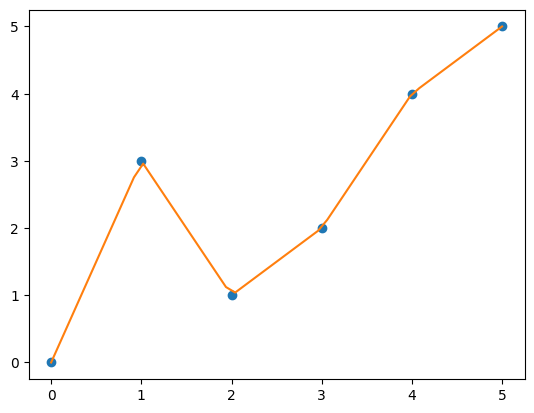

In [138]:
from scipy.interpolate import interp1d
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 3, 1, 2, 4, 5])

f = interp1d(x, y, kind='linear')

X = np.linspace(0, 5, 50)
Y = f(X)
plt.plot(x, y, 'o') 
plt.plot(X, Y, '-')
plt.show()

**quadratic**

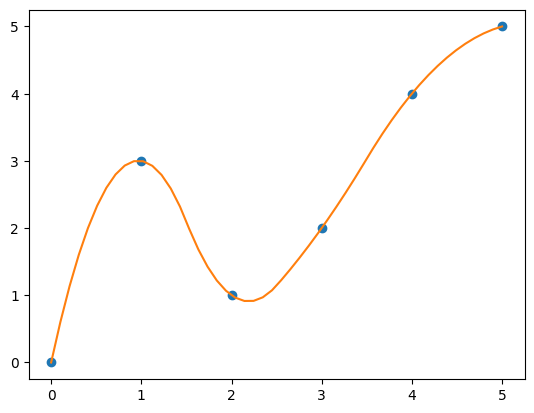

In [139]:
from scipy.interpolate import interp1d
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 3, 1, 2, 4, 5])

f = interp1d(x, y, kind='quadratic')

X = np.linspace(0, 5, 50)
Y = f(X)
plt.plot(x, y, 'o') 
plt.plot(X, Y, '-')
plt.show()

**cubic**

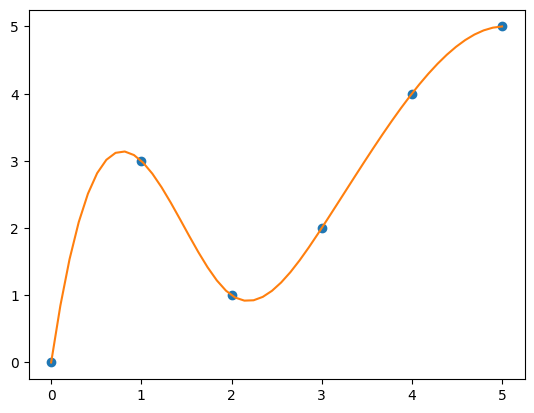

In [140]:
from scipy.interpolate import interp1d
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 3, 1, 2, 4, 5])

f = interp1d(x, y, kind='cubic')

X = np.linspace(0, 5, 50)
Y = f(X)
plt.plot(x, y, 'o') 
plt.plot(X, Y, '-')
plt.show()

**B-Spline interpolation**

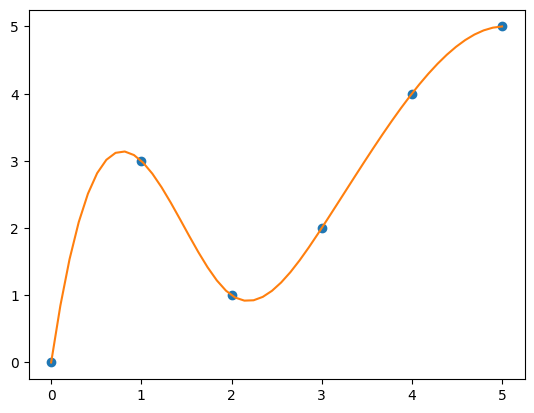

In [141]:
from scipy.interpolate import splrep, splev

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 3, 1, 2, 4, 5])

tck = splrep(x, y, k=3)

X = np.linspace(0, 5, 50)
Y = splev(X, tck)

plt.plot(x, y, 'o', X, Y)
plt.show()

**N-dim regular grid interpolation**

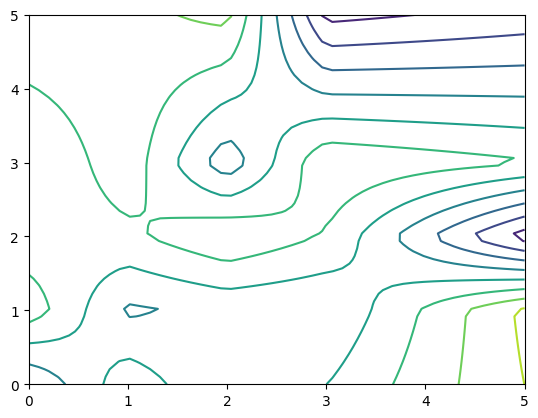

In [172]:
from scipy.interpolate import RegularGridInterpolator
n = 5
x = np.arange(n)
y = np.arange(n)
data = np.random.rand(n,n)

f = RegularGridInterpolator((x, y), data, bounds_error=False, fill_value=None)

X = np.linspace(0, n, 50)
Y = np.linspace(0, n, 50)
X, Y = np.meshgrid(X, Y)

Z = f(np.array([X.ravel(), Y.ravel()]).T).reshape(X.shape)
plt.contour(X, Y, Z)
plt.show()

**scattered data interpolation**

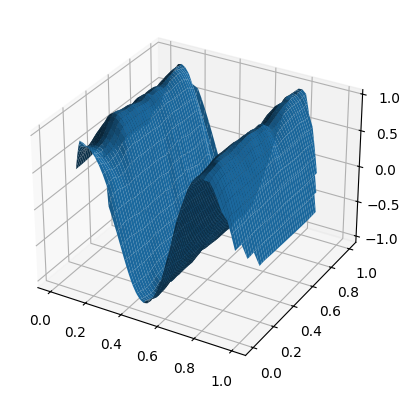

In [ ]:
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

points = np.random.rand(100, 2)
values = np.sin(points[:,0]*10)

grid_x, grid_y = np.mgrid[0:1:50j, 0:1:50j] # 50j means 50 points between 0 and 1

Z = griddata(points, values, (grid_x, grid_y), method='cubic')
ax = plt.subplot(111, projection='3d')
ax.plot_surface(grid_x, grid_y, Z)
plt.show()